In [1]:
import numpy as np

# funciones para la generalización de k-means

def distance(p1,p2): #función para calcular la distancia euclideana
    dist = np.sqrt((p2[0]-p1[0])**2+(p2[1]-p1[1])**2)
    return dist

def compute_centroid(subdata): #función para calcular los centroides
  subdata = np.array(subdata)
  c_x = 1 / len(subdata) * np.sum(subdata[:,0])
  c_y = 1 / len(subdata) * np.sum(subdata[:,1])
  return [c_x, c_y]

#algoritmo de kmeans generalizado que devuelve los centroides finales y a que cluster pertenece cada punto (labels)
def kmeans(puntos, centroids, max_iter=100, tol=1e-2):
  for i in range(max_iter):
    labels = []
    new_centroids = []
    for p in puntos:
      distances = [distance(p, c) for c in centroids]
      labels.append(np.argmin(distances)) #asigna cada punto al centroide inicial más cercano
    labels = np.array(labels)
    for j in range(len(centroids)):
      cluster_points = puntos[labels == j]
      if len(cluster_points) > 0:
          new_centroids.append(compute_centroid(cluster_points)) #se actualizan los centroides
      else:
          new_centroids.append(centroids[j]) #se mantiene el centroide anterior si no hay puntos en el cluster
    new_centroids = np.array(new_centroids)
    shift = np.linalg.norm(new_centroids - centroids)
    if shift < tol:
      print(f"Convergencia alcanzada en {i+1} iteraciones.")
      break
    centroids = new_centroids
  return centroids, labels

In [ ]:
#ejemplo
dataset = np.array([
    [1, 1],
    [2, 2],
    [8, 8],
    [9, 9],
    [8, 9],
    [9, 8]
])

# Initial Centroids
C1, C2, C3 = [1,1], [5,5], [7,7]
centroids = np.array([C1, C2, C3])

centroids, labels = kmeans(dataset, centroids)

print("Centroides finales:")
print(centroids)
print("Etiquetas asignadas:")
print(labels)

Convergencia alcanzada en 2 iteraciones.
Centroides finales:
[[1.5 1.5]
 [5.  5. ]
 [8.5 8.5]]
Etiquetas asignadas:
[0 0 2 2 2 2]


In [8]:
#ejercicio de calcular el centro de masa

#data
puntos = np.loadtxt('scatter_points.txt', skiprows=1)
puntos

array([[16.824244,  3.900979],
       [23.726364,  2.874022],
       [21.858049, 10.343454],
       ...,
       [36.658084, 26.838146],
       [36.995179, 30.946356],
       [39.243456, 30.853685]])

In [10]:
#centroides iniciales
CI = np.array([[10, 10],[40, 10],[20,15]])

centros_finales, etiquetas = kmeans(puntos, CI)
print(centros_finales)

Convergencia alcanzada en 30 iteraciones.
[[ 8.04640031 12.77180142]
 [27.27258132 21.21607216]
 [24.94563639  6.46909927]]


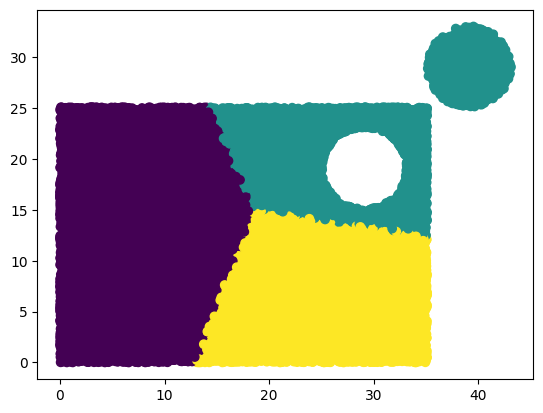

In [11]:
import matplotlib.pyplot as plt

plt.scatter(puntos[:, 0], puntos[:, 1], c=etiquetas, cmap='viridis')